In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/sanjanasanju/Desktop/titanic-classifier/data/train.csv')
print(df.shape)
print(df.head())
print(df.isnull().sum())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [2]:
# Drop useless columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill 2 missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode Sex: male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Add FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(df.shape)
print(df.head())
print(df.isnull().sum())

(891, 10)
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  \
0         0       3    0  22.0      1      0   7.2500       False        True   
1         1       1    1  38.0      1      0  71.2833       False       False   
2         1       3    1  26.0      0      0   7.9250       False        True   
3         1       1    1  35.0      1      0  53.1000       False        True   
4         0       3    0  35.0      0      0   8.0500       False        True   

   FamilySize  
0           2  
1           2  
2           1  
3           2  
4           1  
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
FamilySize    0
dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, preds))
print(classification_report(y_val, preds))

Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



CV Scores: [0.77653631 0.79213483 0.87078652 0.78089888 0.82022472]
Mean: 0.808 (+/- 0.035)


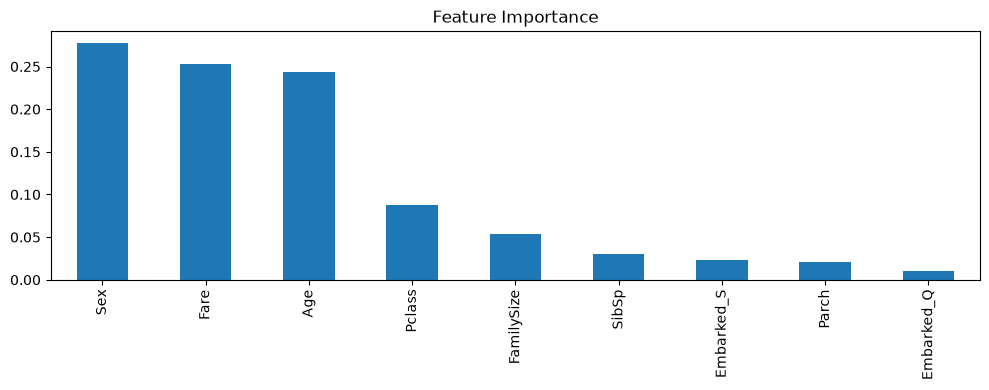

In [4]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Cross validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("CV Scores:", cv_scores)
print(f"Mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import GridSearchCV

# Smaller grid - much faster
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_preds = grid.best_estimator_.predict(X_val)
print("Tuned Accuracy:", accuracy_score(y_val, best_preds))

Best params: {'max_depth': 5, 'n_estimators': 100}
Best CV score: 0.8244394804335237
Tuned Accuracy: 0.8100558659217877


In [6]:
import joblib
joblib.dump(grid.best_estimator_, '/Users/sanjanasanju/Desktop/titanic-classifier/models/titanic_tuned_model.pkl')
print("Tuned model saved.")

Tuned model saved.
